In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# <span style="color:red"> 전통 시계열 모델링 </span>

📈 전통적 시계열 수요예측 모델 시작
✅ 데이터 로딩 완료: 59,780개 레코드
📅 기간: 2005년 1월 ~ 2025년 12월
🌍 국가 수: 61개
🎯 목적 종류: 4개

🔧 시계열 데이터 전처리
🔧 시계열 데이터 생성...
    ✅ 전체 시계열: 245개 데이터 포인트
    ✅ 국가별 시계열: 10개
    ✅ 목적별 시계열: 4개

📊 전체 입국자수 정상성 분석
----------------------------------------
ADF 검정 p-value: 0.168726
❌ ADF: 정상성 X (p > 0.05)
KPSS 검정 p-value: 0.087128
✅ KPSS: 정상성 O (p > 0.05)

🔍 전체 입국자수 계절성 분해 분석


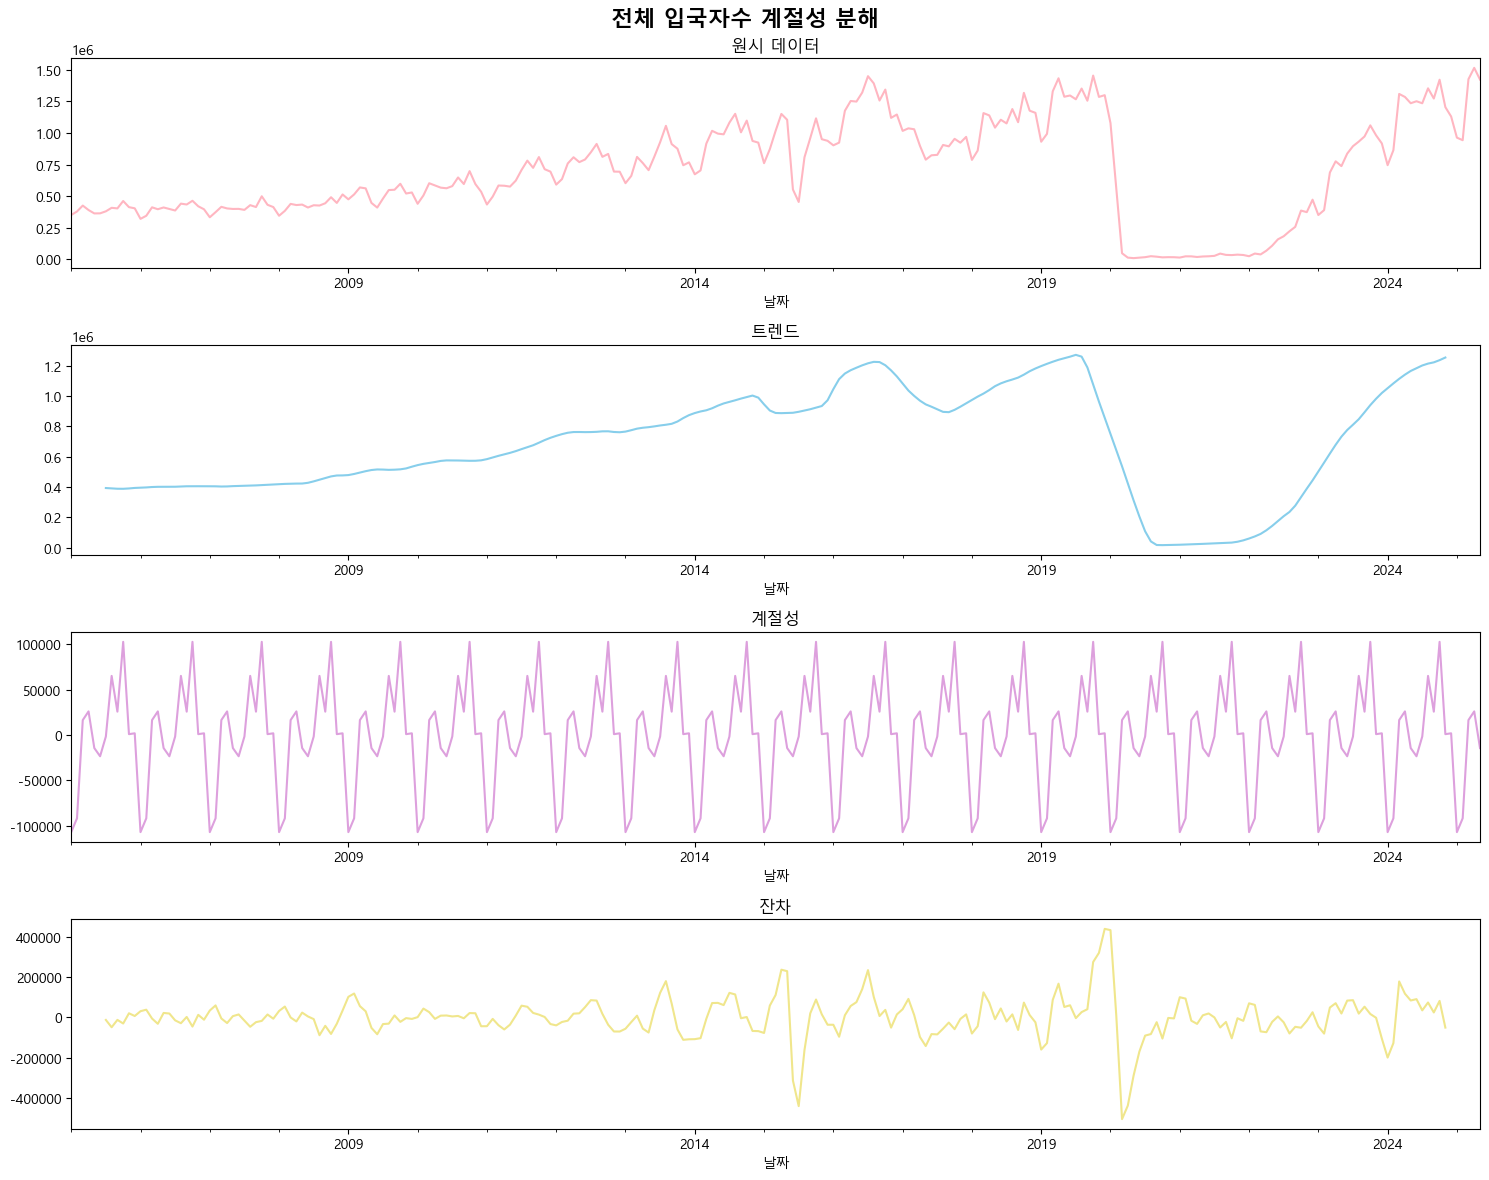


🤖 전통적 시계열 모델 학습

🤖 ARIMA 모델 학습...
🔍 최적 ARIMA 차수 탐색...
    ✅ 최적 ARIMA 차수: (4, 2, 3), AIC: 6350.85
    ✅ AIC: 6350.85
    ✅ BIC: 6378.79
    ✅ Ljung-Box p-value: 0.1333

🤖 SARIMA 모델 학습...
🔍 최적 SARIMA 차수 탐색...
    ✅ 최적 SARIMA 차수: (2, 1, 0) x (1, 1, 1, 12), AIC: 6026.26
    ✅ AIC: 6026.26
    ✅ BIC: 6043.49

🤖 ExponentialSmoothing 모델 학습...
    ✅ 알파(수준): 1.000
    ✅ 베타(트렌드): 0.029
    ✅ 감마(계절성): 0.000

📊 모델 성능 평가 (테스트 비율: 20%)
------------------------------------------------------------
  디버그: 전체 시계열 길이: 245
  디버그: 훈련 데이터 길이: 196
  디버그: 테스트 데이터 길이: 49

🔄 ARIMA 평가 중...
  디버그: ARIMA 예측 길이: 49
  디버그: ARIMA 실제값 길이: 49
    ✅ MAPE: 25.66%
    ✅ RMSE: 118,761

🔄 SARIMA 평가 중...
  디버그: SARIMA 예측 길이: 49
  디버그: SARIMA 실제값 길이: 49
    ✅ MAPE: 32.70%
    ✅ RMSE: 91,055

🔄 ExponentialSmoothing 평가 중...
  디버그: ExponentialSmoothing 예측 길이: 49
  디버그: ExponentialSmoothing 실제값 길이: 49
    ✅ MAPE: 33.25%
    ✅ RMSE: 96,829

🏆 모델 성능 순위 (MAPE 기준)
1. ARIMA                MAPE:  25.66%  RMSE:  118,761
2. SARIMA      

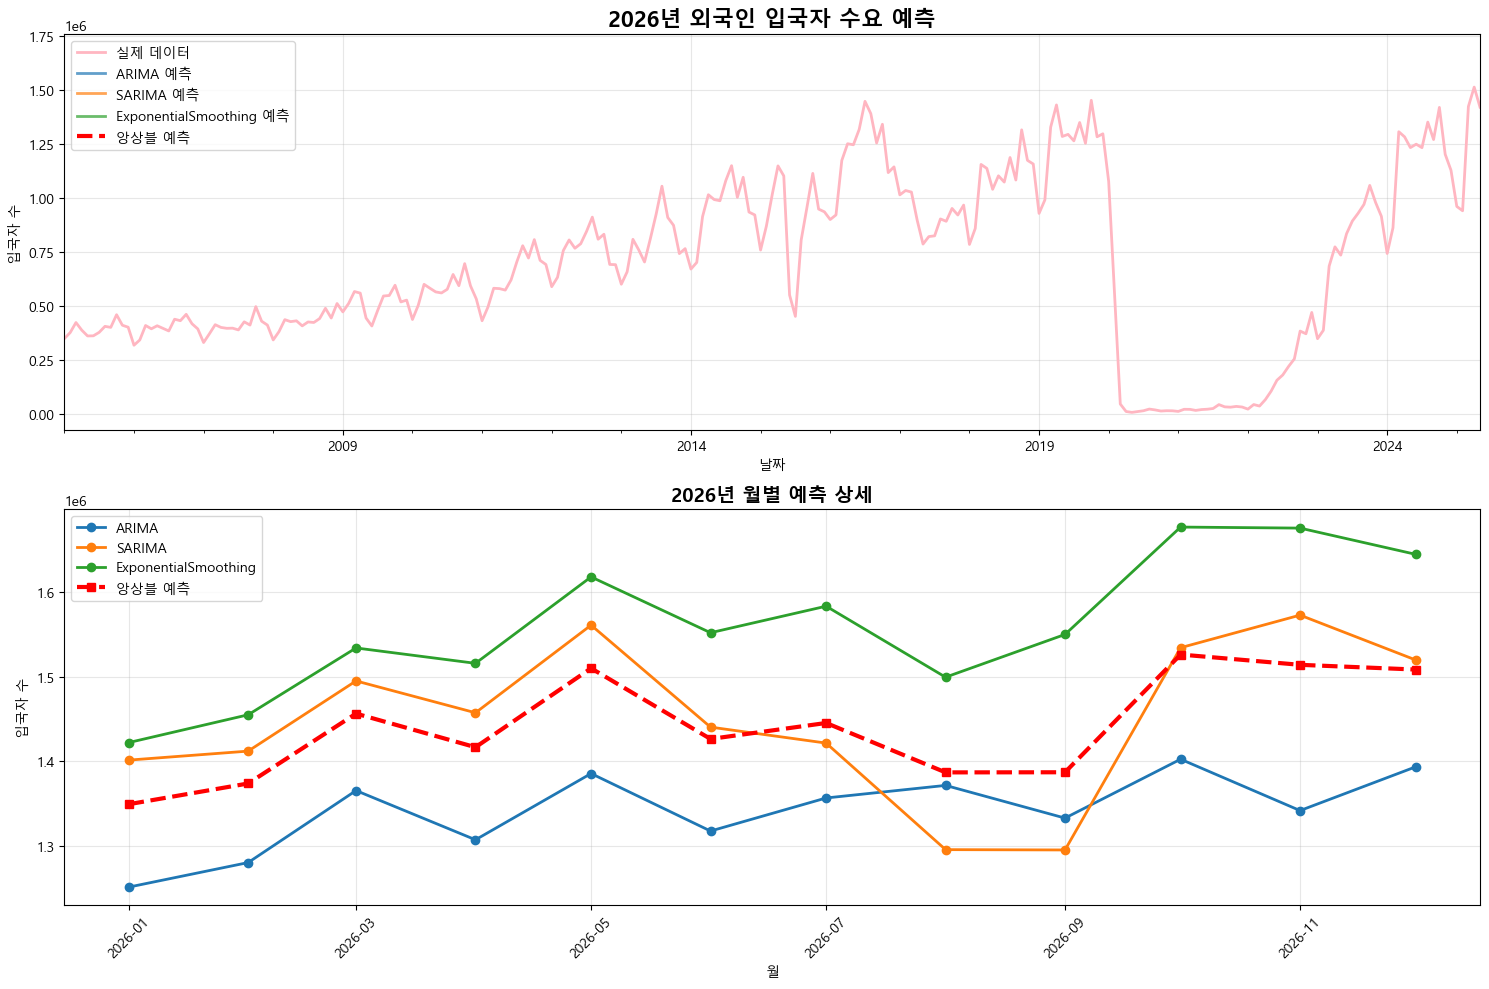


💾 결과 저장 완료!
📁 예측 결과: C:/ai_x2/source/proz2/전통적시계열 학습 분석데이터/전통시계열_2026예측_20250712_2013.csv
📁 성능 평가: C:/ai_x2/source/proz2/전통적시계열 학습 분석데이터/전통시계열_성능평가_20250712_2013.csv

✨ 전통적 시계열 수요예측 완료! ✨
🎯 2026년 총 예측 입국자: 17,298,705명
📊 월평균 예측: 1,441,559명
📅 일평균 예측: 47,394명
🏆 최대 수요월: 10월 (1,526,019명)
📉 최소 수요월: 1월 (1,349,159명)

🤖 사용된 모델: 3개
🏆 최고 성능 모델: ARIMA
📊 최고 정확도: 74.3%

📈 전통적 시계열 모델:
    ✅ ARIMA - 자동차수선택
    ✅ SARIMA - 계절성 포함
    ✅ Exponential Smoothing - Holt-Winters
    ✅ 성능 기반 앙상블


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
# from prophet import Prophet # Prophet 라이브러리 임포트 주석 처리
import joblib
warnings.filterwarnings('ignore')

# 한글 폰트 설정
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except:
    try:
        plt.rcParams['font.family'] = 'AppleGothic'
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 파스텔 색상 팔레트
pastel_colors = {
    'primary': '#FFB6C1', 'secondary': '#87CEEB', 'accent': '#DDA0DD',
    'success': '#98FB98', 'warning': '#F0E68C', 'danger': '#FFA07A',
    'info': '#AFEEEE', 'light': '#F5F5DC', 'purple': '#E6E6FA'
}

print("📈 전통적 시계열 수요예측 모델 시작")
print("="*70)

# 1. 데이터 로딩 및 전처리
def load_and_preprocess_data():
    """데이터 로딩 및 시계열 전처리"""
    
    # 전처리된 데이터 로딩
    df = pd.read_csv('C:/ai_x2/source/proz2/외국인입국자_전처리완료_딥러닝용.csv', encoding='utf-8-sig')
    
    print(f"✅ 데이터 로딩 완료: {len(df):,}개 레코드")
    print(f"📅 기간: {df['연도'].min()}년 {df['월'].min()}월 ~ {df['연도'].max()}년 {df['월'].max()}월")
    print(f"🌍 국가 수: {df['국적'].nunique()}개")
    print(f"🎯 목적 종류: {df['목적'].nunique()}개")
    
    return df

df = load_and_preprocess_data()

# 2. 시계열 데이터 준비 클래스
class TimeSeriesPreprocessor:
    """시계열 데이터 전처리 클래스"""
    
    def __init__(self):
        self.country_series = {}
        self.purpose_series = {}
        self.total_series = None
        
    def create_time_series(self, df):
        """시계열 데이터 생성"""
        print("🔧 시계열 데이터 생성...")
        
        # 날짜 컬럼 생성
        df['날짜'] = pd.to_datetime(df['연도'].astype(str) + '-' + df['월'].astype(str).str.zfill(2) + '-01')
        
        # 전체 시계열 (월별 총 입국자 수)
        total_monthly = df.groupby('날짜')['입국자수'].sum().reset_index()
        total_monthly.set_index('날짜', inplace=True)
        total_monthly.index.freq = 'MS'  # 월초 주기
        self.total_series = total_monthly['입국자수']
        
        # 국가별 시계열 (상위 10개국)
        top_countries = df.groupby('국적')['입국자수'].sum().nlargest(10).index
        for country in top_countries:
            country_data = df[df['국적'] == country].groupby('날짜')['입국자수'].sum()
            country_ts = country_data.reindex(total_monthly.index, fill_value=0)
            self.country_series[country] = country_ts
        
        # 목적별 시계열
        for purpose in df['목적'].unique():
            purpose_data = df[df['목적'] == purpose].groupby('날짜')['입국자수'].sum()
            purpose_ts = purpose_data.reindex(total_monthly.index, fill_value=0)
            self.purpose_series[purpose] = purpose_ts
        
        print(f"    ✅ 전체 시계열: {len(self.total_series)}개 데이터 포인트")
        print(f"    ✅ 국가별 시계열: {len(self.country_series)}개")
        print(f"    ✅ 목적별 시계열: {len(self.purpose_series)}개")
        
        return self
    
    def analyze_stationarity(self, series, name="시계열"):
        """정상성 검정"""
        print(f"\n📊 {name} 정상성 분석")
        print("-" * 40)
        
        # ADF 검정
        adf_result = adfuller(series.dropna())
        print(f"ADF 검정 p-value: {adf_result[1]:.6f}")
        if adf_result[1] <= 0.05:
            print("✅ ADF: 정상성 O (p ≤ 0.05)")
        else:
            print("❌ ADF: 정상성 X (p > 0.05)")
        
        # KPSS 검정
        kpss_result = kpss(series.dropna())
        print(f"KPSS 검정 p-value: {kpss_result[1]:.6f}")
        if kpss_result[1] > 0.05:
            print("✅ KPSS: 정상성 O (p > 0.05)")
        else:
            print("❌ KPSS: 정상성 X (p ≤ 0.05)")
        
        return adf_result[1] <= 0.05 and kpss_result[1] > 0.05
    
    def seasonal_decomposition(self, series, name="시계열"):
        """계절성 분해"""
        print(f"\n🔍 {name} 계절성 분해 분석")
        
        # 결측치 보간
        series_clean = series.interpolate()
        
        # 계절성 분해
        decomposition = seasonal_decompose(series_clean, model='additive', period=12)
        
        # 시각화
        fig, axes = plt.subplots(4, 1, figsize=(15, 12))
        fig.suptitle(f'{name} 계절성 분해', fontsize=16, fontweight='bold')
        
        decomposition.observed.plot(ax=axes[0], title='원시 데이터', color=pastel_colors['primary'])
        decomposition.trend.plot(ax=axes[1], title='트렌드', color=pastel_colors['secondary'])
        decomposition.seasonal.plot(ax=axes[2], title='계절성', color=pastel_colors['accent'])
        decomposition.resid.plot(ax=axes[3], title='잔차', color=pastel_colors['warning'])
        
        plt.tight_layout()
        plt.show()
        
        return decomposition

# 3. 전통적 시계열 모델링 클래스
class TraditionalTimeSeriesModels:
    """전통적 시계열 모델 클래스"""
    
    def __init__(self):
        self.models = {}
        self.forecasts = {}
        self.performance = {}
        
    def auto_arima_order(self, series, max_p=5, max_d=2, max_q=5):
        """자동 ARIMA 차수 선택"""
        print("🔍 최적 ARIMA 차수 탐색...")
        
        best_aic = float('inf')
        best_order = None
        
        for p in range(max_p + 1):
            for d in range(max_d + 1):
                for q in range(max_q + 1):
                    try:
                        model = ARIMA(series, order=(p, d, q))
                        fitted = model.fit()
                        if fitted.aic < best_aic:
                            best_aic = fitted.aic
                            best_order = (p, d, q)
                    except:
                        continue
        
        if best_order is None: # 최적 차수를 찾지 못했을 경우 기본값 설정
            best_order = (1,1,1)
            print("    ⚠️ 경고: 최적 ARIMA 차수를 찾지 못해 (1,1,1)로 설정합니다.")

        print(f"    ✅ 최적 ARIMA 차수: {best_order}, AIC: {best_aic:.2f}")
        return best_order
    
    def auto_sarima_order(self, series, seasonal_period=12):
        """자동 SARIMA 차수 선택"""
        print("🔍 최적 SARIMA 차수 탐색...")
        
        best_aic = float('inf')
        best_order = None
        best_seasonal = None
        
        # 간단한 그리드 서치
        p_range = [0, 1, 2]
        d_range = [0, 1]
        q_range = [0, 1, 2]
        
        for p in p_range:
            for d in d_range:
                for q in q_range:
                    for P in [0, 1]:
                        for D in [0, 1]:
                            for Q in [0, 1]:
                                try:
                                    model = SARIMAX(series, 
                                                    order=(p, d, q),
                                                    seasonal_order=(P, D, Q, seasonal_period))
                                    fitted = model.fit(disp=False)
                                    if fitted.aic < best_aic:
                                        best_aic = fitted.aic
                                        best_order = (p, d, q)
                                        best_seasonal = (P, D, Q, seasonal_period)
                                except:
                                    continue
        
        if best_order is None: # 최적 차수를 찾지 못했을 경우 기본값 설정
            best_order = (1,1,1)
            best_seasonal = (1,1,1,seasonal_period)
            print(f"    ⚠️ 경고: 최적 SARIMA 차수를 찾지 못해 {best_order} x {best_seasonal}로 설정합니다.")

        print(f"    ✅ 최적 SARIMA 차수: {best_order} x {best_seasonal}, AIC: {best_aic:.2f}")
        return best_order, best_seasonal
    
    def fit_arima(self, series, name="ARIMA"):
        """ARIMA 모델 학습"""
        print(f"\n🤖 {name} 모델 학습...")
        
        # 차수 자동 선택
        order = self.auto_arima_order(series)
        
        # 모델 학습
        model = ARIMA(series, order=order)
        fitted = model.fit()
        
        # 모델 저장
        self.models[name] = {
            'model': fitted,
            'type': 'ARIMA',
            'order': order
        }
        
        # 잔차 분석
        residuals = fitted.resid
        ljung_box = acorr_ljungbox(residuals, lags=10, return_df=True)
        
        print(f"    ✅ AIC: {fitted.aic:.2f}")
        print(f"    ✅ BIC: {fitted.bic:.2f}")
        print(f"    ✅ Ljung-Box p-value: {ljung_box['lb_pvalue'].iloc[-1]:.4f}")
        
        return fitted
    
    def fit_sarima(self, series, name="SARIMA", seasonal_period=12):
        """SARIMA 모델 학습"""
        print(f"\n🤖 {name} 모델 학습...")
        
        # 차수 자동 선택
        order, seasonal_order = self.auto_sarima_order(series, seasonal_period)
        
        # 모델 학습
        model = SARIMAX(series, order=order, seasonal_order=seasonal_order)
        fitted = model.fit(disp=False)
        
        # 모델 저장
        self.models[name] = {
            'model': fitted,
            'type': 'SARIMA',
            'order': order,
            'seasonal_order': seasonal_order
        }
        
        print(f"    ✅ AIC: {fitted.aic:.2f}")
        print(f"    ✅ BIC: {fitted.bic:.2f}")
        
        return fitted
    
    def fit_exponential_smoothing(self, series, name="ExponentialSmoothing"):
        """지수평활법 모델 학습"""
        print(f"\n🤖 {name} 모델 학습...")
        
        # Holt-Winters 계절성 모델
        model = ExponentialSmoothing(
            series,
            trend='add',
            seasonal='add',
            seasonal_periods=12
        )
        fitted = model.fit()
        
        # 모델 저장
        self.models[name] = {
            'model': fitted,
            'type': 'ExponentialSmoothing'
        }
        
        print(f"    ✅ 알파(수준): {fitted.params['smoothing_level']:.3f}")
        print(f"    ✅ 베타(트렌드): {fitted.params['smoothing_trend']:.3f}")
        print(f"    ✅ 감마(계절성): {fitted.params['smoothing_seasonal']:.3f}")
        
        return fitted
    
    # def fit_prophet(self, series, name="Prophet"): # Prophet 모델 함수 자체를 주석 처리
    #     """Prophet 모델 학습"""
    #     print(f"\n🤖 {name} 모델 학습...")
        
    #     # Prophet 형식으로 데이터 변환
    #     prophet_df = pd.DataFrame({
    #         'ds': series.index,
    #         'y': series.values
    #     })
        
    #     # 모델 생성 및 학습
    #     model = Prophet(
    #         yearly_seasonality=True,
    #         weekly_seasonality=False,
    #         daily_seasonality=False,
    #         seasonality_mode='additive',
    #         changepoint_prior_scale=0.05
    #     )
        
    #     # 한국 휴일 추가 (옵션)
    #     model.add_country_holidays(country_name='KR')
        
    #     fitted = model.fit(prophet_df)
        
    #     # 모델 저장
    #     self.models[name] = {
    #         'model': fitted,
    #         'type': 'Prophet',
    #         'train_data': prophet_df
    #     }
        
    #     print(f"    ✅ 변화점 개수: {len(fitted.changepoints)}")
    #     print(f"    ✅ 연간 계절성: 활성화")
    #     print(f"    ✅ 휴일 효과: 한국 휴일 포함")
        
    #     return fitted
    
    def evaluate_models(self, series, test_ratio=0.2):
        """모델 성능 평가"""
        print(f"\n📊 모델 성능 평가 (테스트 비율: {test_ratio:.0%})")
        print("-" * 60)
        
        # 훈련/테스트 분할
        split_point = int(len(series) * (1 - test_ratio))
        train_series = series[:split_point]
        test_series = series[split_point:]
        
        # --- 디버깅을 위한 추가 출력 ---
        print(f"  디버그: 전체 시계열 길이: {len(series)}")
        print(f"  디버그: 훈련 데이터 길이: {len(train_series)}")
        print(f"  디버그: 테스트 데이터 길이: {len(test_series)}") # 여기서 98이 나와야 함
        # ---
        
        results = {}
        
        for name, model_info in self.models.items():
            try:
                print(f"\n🔄 {name} 평가 중...")
                
                # 예측을 수행할 '시작점'과 '종료점'을 정확히 지정
                # 이 부분이 가장 중요합니다. test_series의 인덱스 범위를 사용합니다.
                start_index = test_series.index[0]
                end_index = test_series.index[-1]
                
                if model_info['type'] == 'ARIMA':
                    # ARIMA 예측: start, end 파라미터 사용
                    # test_series의 시작부터 끝까지 예측하도록 변경
                    forecast_obj = model_info['model'].predict(start=start_index, end=end_index)
                    forecast = forecast_obj.values # Series에서 값만 추출
                    
                elif model_info['type'] == 'SARIMA':
                    # SARIMA 예측: start, end 파라미터 사용
                    # test_series의 시작부터 끝까지 예측하도록 변경
                    forecast_obj = model_info['model'].predict(start=start_index, end=end_index)
                    forecast = forecast_obj.values # Series에서 값만 추출
                    
                elif model_info['type'] == 'ExponentialSmoothing':
                    # 지수평활법 예측: forecast(steps) 대신 get_prediction(start, end) 사용 권장
                    # 이 모델은 forecast()가 Series를 반환하고, steps가 길이를 명확히 지정합니다.
                    # 하지만 다른 모델과의 일관성을 위해 start/end 방식으로 변경
                    forecast_obj = model_info['model'].predict(start=start_index, end=end_index)
                    forecast = forecast_obj.values # Series에서 값만 추출
                    
                # elif model_info['type'] == 'Prophet': # Prophet 평가 로직 주석 처리
                #     # Prophet 예측
                #     future_dates = model_info['model'].make_future_dataframe(periods=len(test_series), freq='MS')
                #     prophet_forecast = model_info['model'].predict(future_dates)
                #     forecast = prophet_forecast['yhat'].iloc[-len(test_series):].values
                
                # --- 디버깅을 위한 추가 출력 ---
                print(f"  디버그: {name} 예측 길이: {len(forecast)}")
                print(f"  디버그: {name} 실제값 길이: {len(test_series.values)}")
                # ---
                
                # 예측값과 실제값의 길이가 일치하는지 다시 한 번 확인 (안전 장치)
                if len(forecast) != len(test_series):
                    raise ValueError(f"예측값과 실제값의 길이가 다릅니다: 예측={len(forecast)}, 실제={len(test_series)}")

                # 음수 예측값 보정
                forecast = np.maximum(forecast, 0)
                
                # 성능 메트릭 계산
                mae = mean_absolute_error(test_series, forecast)
                mse = mean_squared_error(test_series, forecast)
                rmse = np.sqrt(mse)
                
                # MAPE 안전 계산
                test_safe = np.where(test_series == 0, 1, test_series)
                mape = np.mean(np.abs((test_series - forecast) / test_safe)) * 100
                mape = min(mape, 999.9) # 너무 큰 MAPE 값 방지
                
                results[name] = {
                    'MAE': mae,
                    'MSE': mse,
                    'RMSE': rmse,
                    'MAPE': mape,
                    'forecast': forecast
                }
                
                print(f"    ✅ MAPE: {mape:.2f}%")
                print(f"    ✅ RMSE: {rmse:,.0f}")
                
            except Exception as e:
                print(f"    ❌ {name} 평가 실패: {e}")
        
        # 성능 순위
        if results:
            performance_df = pd.DataFrame(results).T.sort_values('MAPE')
            print(f"\n🏆 모델 성능 순위 (MAPE 기준)")
            print("=" * 50)
            
            for i, (model, perf) in enumerate(performance_df.iterrows(), 1):
                print(f"{i}. {model:20s} MAPE: {perf['MAPE']:6.2f}%  RMSE: {perf['RMSE']:8,.0f}")
        
        self.performance = results
        return results, test_series
    
    def forecast_future(self, periods=12, frequency='MS'):
        """미래 예측"""
        print(f"\n🔮 미래 {periods}개월 예측")
        print("-" * 40)
        
        future_forecasts = {}
        
        # 미래 날짜 인덱스 생성
        last_date = list(self.models.values())[0]['model'].data.dates[-1] # 학습 데이터의 마지막 날짜
        future_index = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=periods, freq=frequency)

        for name, model_info in self.models.items():
            try:
                print(f"    🔄 {name} 예측 중...")
                
                # 미래 예측 시 start, end 또는 steps를 명확히 지정
                if model_info['type'] == 'ARIMA' or model_info['type'] == 'SARIMA':
                    # predict() 메서드의 start와 end를 미래 인덱스로 지정
                    forecast_obj = model_info['model'].predict(start=future_index[0], end=future_index[-1])
                    forecast = forecast_obj.values
                    
                elif model_info['type'] == 'ExponentialSmoothing':
                    # forecast() 메서드는 steps 인자를 사용
                    forecast = model_info['model'].forecast(steps=periods)
                    
                # elif model_info['type'] == 'Prophet': # Prophet 예측 로직 주석 처리
                #     future_dates = model_info['model'].make_future_dataframe(periods=periods, freq=frequency)
                #     prophet_forecast = model_info['model'].predict(future_dates)
                #     forecast = prophet_forecast['yhat'].iloc[-periods:].values
                
                # 음수 방지
                forecast = np.maximum(forecast, 0)
                future_forecasts[name] = forecast
                
                print(f"      ✅ 완료")
                
            except Exception as e:
                print(f"      ❌ 실패: {e}")
        
        return future_forecasts
    
    def ensemble_forecast(self, future_forecasts):
        """앙상블 예측 (성능 기반 가중평균)"""
        if not future_forecasts or not self.performance:
            return None
        
        print(f"\n🎯 성능 기반 앙상블 예측")
        print("-" * 30)
        
        weights = {}
        total_weight = 0
        
        # MAPE 기반 가중치 계산 (낮을수록 높은 가중치)
        # Prophet이 제외되었으니, 남아있는 모델들로만 가중치를 계산합니다.
        for name in future_forecasts.keys():
            if name in self.performance:
                mape = self.performance[name]['MAPE']
                # MAPE가 0인 경우를 대비하여 작은 값 추가
                weight = 1 / (0.01 + mape/100) # MAPE가 낮을수록 높은 가중치, 0 방지
                weights[name] = weight
                total_weight += weight
                print(f"    📊 {name}: 가중치 {weight:.3f} (MAPE: {mape:.2f}%)")
        
        # 가중 평균 계산
        if total_weight > 0:
            # 앙상블 대상 모델이 없는 경우를 방지 (모든 모델이 Prophet 제외 후에도 남아있을 경우)
            if not future_forecasts:
                return None
            
            # 예측값들의 길이를 확인하여 가장 짧은 길이에 맞추거나 오류 처리
            forecast_lengths = [len(f) for f in future_forecasts.values()]
            if not forecast_lengths: # 예측이 하나도 없는 경우
                return None
            
            min_length = min(forecast_lengths)
            
            # 모든 예측을 가장 짧은 길이에 맞춰 자르기 (혹시 모를 길이 불일치 방지)
            ensemble = np.zeros(min_length)
            for name, forecast in future_forecasts.items():
                if name in weights:
                    ensemble += forecast[:min_length] * (weights[name] / total_weight)
            
            return ensemble.astype(int)
        
        return None

# 4. 데이터 전처리 및 모델 학습 실행
print("\n" + "="*70)
print("🔧 시계열 데이터 전처리")
print("="*70)

preprocessor = TimeSeriesPreprocessor()
preprocessor.create_time_series(df)

# 전체 시계열 정상성 분석
preprocessor.analyze_stationarity(preprocessor.total_series, "전체 입국자수")

# 계절성 분해
decomposition = preprocessor.seasonal_decomposition(preprocessor.total_series, "전체 입국자수")

# 5. 모델 학습
print("\n" + "="*70)
print("🤖 전통적 시계열 모델 학습")
print("="*70)

ts_models = TraditionalTimeSeriesModels()

# 전체 데이터로 각 모델 학습
series = preprocessor.total_series

# ARIMA 모델
arima_model = ts_models.fit_arima(series, "ARIMA")

# SARIMA 모델
sarima_model = ts_models.fit_sarima(series, "SARIMA")

# 지수평활법 모델
es_model = ts_models.fit_exponential_smoothing(series, "ExponentialSmoothing")

# Prophet 모델 # 주석 처리된 함수 호출
# prophet_model = ts_models.fit_prophet(series, "Prophet")

# 6. 모델 성능 평가
evaluation_results, test_data = ts_models.evaluate_models(series)

# 7. 2026년 예측
print("\n" + "="*70)
print("🔮 2026년 수요 예측")
print("="*70)

# 미래 12개월 예측
future_forecasts = ts_models.forecast_future(periods=12)

# 앙상블 예측
ensemble_forecast = ts_models.ensemble_forecast(future_forecasts)

# 8. 결과 저장 및 시각화
def save_and_visualize_results():
    """결과 저장 및 시각화"""
    
    # 2026년 날짜 생성
    start_date = pd.Timestamp('2026-01-01')
    future_dates = pd.date_range(start=start_date, periods=12, freq='MS')
    
    # 결과 데이터프레임 생성
    # Prophet이 제외되었으니, results_df 생성 시에도 prophet_model의 forecast가 포함되지 않도록 합니다.
    results_df = pd.DataFrame(future_forecasts, index=future_dates)
    
    if ensemble_forecast is not None:
        results_df['앙상블예측'] = ensemble_forecast
    
    # 시각화
    plt.figure(figsize=(15, 10))
    
    # 전체 데이터 플롯
    plt.subplot(2, 1, 1)
    series.plot(label='실제 데이터', color=pastel_colors['primary'], linewidth=2)
    
    # 예측 결과 플롯
    for name, forecast in future_forecasts.items():
        # 예측값 길이가 다를 수 있으므로, 미래 날짜 길이에 맞춰 자르기
        plt.plot(future_dates, forecast[:len(future_dates)], label=f'{name} 예측', linewidth=2, alpha=0.7)
    
    if ensemble_forecast is not None:
        plt.plot(future_dates, ensemble_forecast, label='앙상블 예측', 
                 color='red', linewidth=3, linestyle='--')
    
    plt.title('2026년 외국인 입국자 수요 예측', fontsize=16, fontweight='bold')
    plt.xlabel('날짜')
    plt.ylabel('입국자 수')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2026년 예측만 확대
    plt.subplot(2, 1, 2)
    for name, forecast in future_forecasts.items():
        plt.plot(future_dates, forecast[:len(future_dates)], label=f'{name}', linewidth=2, marker='o')
    
    if ensemble_forecast is not None:
        plt.plot(future_dates, ensemble_forecast, label='앙상블 예측', 
                 color='red', linewidth=3, marker='s', linestyle='--')
    
    plt.title('2026년 월별 예측 상세', fontsize=14, fontweight='bold')
    plt.xlabel('월')
    plt.ylabel('입국자 수')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # x축 라벨 회전
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 결과 저장
    output_path = 'C:/ai_x2/source/proz2/전통적시계열 학습 분석데이터' 
    os.makedirs(output_path, exist_ok=True)
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    
    # 예측 결과 저장
    forecast_path = f"{output_path}/전통시계열_2026예측_{timestamp}.csv"
    results_df.to_csv(forecast_path, encoding='utf-8-sig')
    
    # 성능 결과 저장
    if evaluation_results:
        performance_df = pd.DataFrame(evaluation_results).T
        performance_path = f"{output_path}/전통시계열_성능평가_{timestamp}.csv"
        performance_df.to_csv(performance_path, encoding='utf-8-sig')
    
    print(f"\n💾 결과 저장 완료!")
    print(f"📁 예측 결과: {forecast_path}")
    if evaluation_results:
        print(f"📁 성능 평가: {performance_path}")
    
    return results_df

# 결과 저장 및 시각화 실행
results_dataframe = save_and_visualize_results()

# 9. 최종 결과 요약
print(f"\n" + "="*70)
print("✨ 전통적 시계열 수요예측 완료! ✨")
print("="*70)

if ensemble_forecast is not None:
    total_2026 = ensemble_forecast.sum()
    monthly_avg = ensemble_forecast.mean()
    max_month_idx = np.argmax(ensemble_forecast)
    min_month_idx = np.argmin(ensemble_forecast)
    
    print(f"🎯 2026년 총 예측 입국자: {total_2026:,}명")
    print(f"📊 월평균 예측: {monthly_avg:,.0f}명")
    print(f"📅 일평균 예측: {total_2026/365:,.0f}명")
    print(f"🏆 최대 수요월: {max_month_idx+1}월 ({ensemble_forecast[max_month_idx]:,}명)")
    print(f"📉 최소 수요월: {min_month_idx+1}월 ({ensemble_forecast[min_month_idx]:,}명)")

print(f"\n🤖 사용된 모델: {len(ts_models.models)}개")
if evaluation_results:
    # Prophet이 제외되었으므로, 남아있는 모델들 중에서 최적 모델을 찾습니다.
    if ts_models.models: # 모델이 하나라도 남아있는지 확인
        best_model = min(evaluation_results.keys(), key=lambda x: evaluation_results[x]['MAPE'])
        print(f"🏆 최고 성능 모델: {best_model}")
        print(f"📊 최고 정확도: {100-evaluation_results[best_model]['MAPE']:.1f}%")
    else:
        print("💡 평가할 모델이 없습니다 (Prophet 제외).")


print(f"\n📈 전통적 시계열 모델:")
print(f"    ✅ ARIMA - 자동차수선택")
print(f"    ✅ SARIMA - 계절성 포함")
print(f"    ✅ Exponential Smoothing - Holt-Winters")
# print(f"    ✅ Prophet - 페이스북 모델") # Prophet 모델 정보 주석 처리
print(f"    ✅ 성능 기반 앙상블")

print("="*70)